In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from src.io.hmd_reader import read_hmd_csv
from src.models.lee_carter import fit_lee_carter, forecast_kt, reconstruct_mx
from src.models.life_expectancy import compute_life_expectancy, compute_life_table

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

In [ ]:
df = read_hmd_csv("../data/france_deaths_clean.csv", "../data/france_population_clean.csv")

df.head(5)

,Year,Age,Sex,Deaths,Exposure
0,1816,0,Female,76332.26,390373.68
1,1816,1,Female,17861.24,368928.28
2,1816,2,Female,11924.14,352525.76
3,1816,3,Female,7738.20,341261.43
4,1816,4,Female,5303.44,339910.85


In [ ]:
df_stats = df[df['Sex'] == 'Total'].copy()

df_stats['mx'] = df_stats['Deaths'] / df_stats['Exposure']
df_stats['var_mx'] = df_stats['mx'] / df_stats['Exposure']
df_stats['se_mx'] = np.sqrt(df_stats['var_mx'])

df_stats['qx_lower'] = (df_stats['mx'] - 1.96 * df_stats['se_mx']).clip(lower=0)
df_stats['qx_upper'] = df_stats['mx'] + 1.96 * df_stats['se_mx']

df_stats[df_stats['Year'] == 2019].head()

,Year,Age,Sex,Deaths,Exposure,mx,var_mx,se_mx,qx_lower,qx_upper
66045,2019,0,Total,2540.0,679810.0,0.003736,5.496151e-09,0.000074,0.003591,0.003882
66046,2019,1,Total,186.0,694059.0,0.000268,3.861181e-10,0.000020,0.000229,0.000307
66047,2019,2,Total,134.0,712267.0,0.000188,2.641309e-10,0.000016,0.000156,0.000220
66048,2019,3,Total,77.0,733114.0,0.000105,1.432675e-10,0.000012,0.000082,0.000128
66049,2019,4,Total,81.0,760324.0,0.000107,1.401160e-10,0.000012,0.000083,0.000130


In [ ]:
df_2019 = df_stats[df_stats['Year'] == 2019].copy()
df_2019['ax'] = 0.5
df_2019['qx'] = df_2019['mx'] / (1 + 0.5 * df_2019['mx'])

df_lt = compute_life_table(df_2019)

df_lt.head(10)[['Age', 'mx', 'lx', 'dx', 'Lx', 'Tx', 'ex']]

,Age,mx,lx,dx,Lx,Tx,ex
0,0,0.003736,100000.000000,372.937100,99813.531450,8.264151e+06,82.641508
1,1,0.000268,99627.062900,26.695354,99613.715223,8.164337e+06,81.948991
2,2,0.000188,99600.367546,18.736224,99590.999434,8.064724e+06,80.970822
3,3,0.000105,99581.631322,10.458650,99576.401997,7.965133e+06,79.985962
4,4,0.000107,99571.172672,10.607104,99565.869120,7.865556e+06,78.994311
5,5,0.000087,99560.565568,8.677278,99556.226929,7.765990e+06,78.002674
6,6,0.000076,99551.888290,7.604276,99548.086152,7.666434e+06,77.009429
7,7,0.000071,99544.284014,7.020119,99540.773954,7.566886e+06,76.015274
8,8,0.000054,99537.263895,5.364661,99534.581564,7.467345e+06,75.020600
9,9,0.000084,99531.899233,8.392640,99527.702913,7.367811e+06,74.024616


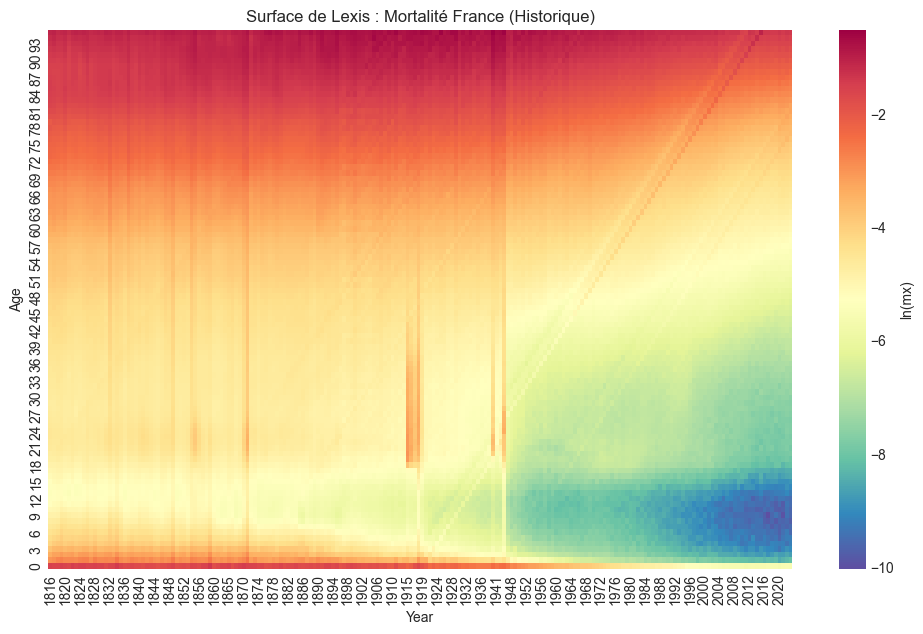

In [ ]:
df_heatmap = df_stats[df_stats['Age'] <= 95].pivot(index="Age", columns="Year", values="mx")
df_heatmap_log = np.log(df_heatmap.replace(0, 1e-9))

sns.heatmap(df_heatmap_log, cmap="Spectral_r", cbar_kws={'label': 'ln(mx)'})
plt.title("Surface de Lexis : Mortalité France (Historique)")
plt.gca().invert_yaxis() 
plt.show()

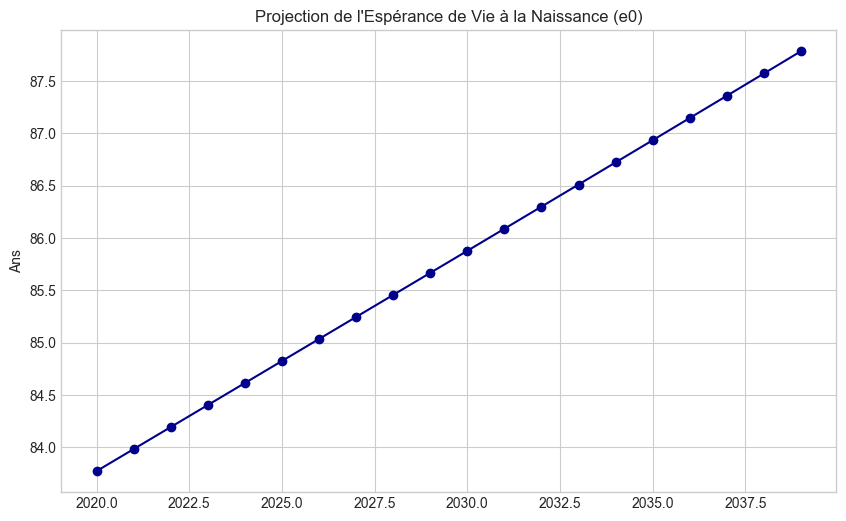

In [ ]:
df_lc = df_stats[(df_stats['Year'] >= 1970) & (df_stats['Year'] <= 2019)]

ax, bx, kt = fit_lee_carter(df_lc)

kt_future = forecast_kt(kt, n_years=20)

mx_future = reconstruct_mx(ax, bx, kt_future)
e0_future = compute_life_expectancy(mx_future)

plt.figure(figsize=(10, 6))
years_fut = range(2020, 2040)
plt.plot(years_fut, e0_future.values, marker='o', linestyle='-', color='darkblue')
plt.title("Projection de l'Espérance de Vie à la Naissance (e0)")
plt.ylabel("Ans")
plt.grid(True)
plt.show()

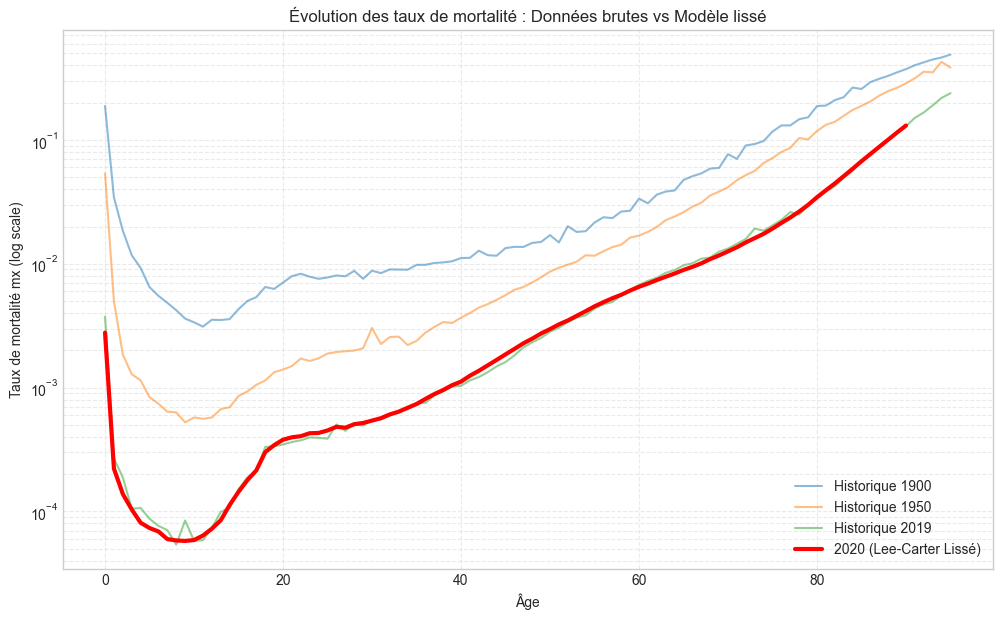

In [ ]:
years_to_plot = [1900, 1950, 2019]
plt.figure(figsize=(12, 7))

for year in years_to_plot:
    # On filtre les données brutes à 95 ans pour la propreté visuelle
    data_year = df_stats[(df_stats['Year'] == year) & (df_stats['Age'] <= 95)]
    plt.plot(data_year['Age'], data_year['mx'], label=f"Historique {year}", alpha=0.5)

plt.plot(mx_future.index, mx_future.iloc[:, 0], 
         label="2020 (Lee-Carter Lissé)", color='red', linewidth=3)

plt.yscale('log')
plt.title("Évolution des taux de mortalité : Données brutes vs Modèle lissé")
plt.xlabel("Âge")
plt.ylabel("Taux de mortalité mx (log scale)")
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.show()

In [ ]:
os.makedirs("../outputs/dashboard", exist_ok=True)
plt.savefig("../outputs/dashboard/lexis_surface.png")
e0_future.to_csv("../outputs/dashboard/france_forecast_e0.csv")
print("Dashboard exporté avec succès.")